## 1. Importations et configurations

In [24]:
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import ipywidgets as widgets
import matplotlib.pyplot as plt


from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix

from sklearn.compose import ColumnTransformer
from IPython.display import display, clear_output
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score

# Configuration pour un meilleur affichage des graphiques
%matplotlib inline
sns.set_theme(style="whitegrid")

## 2. Définition des fonctions utilitaires

In [2]:
def save_plot(folder="image", default_name="figure"):
    """
    Enregistre automatiquement le plot actuel dans le dossier spécifié,
    en utilisant le titre de la figure comme nom de fichier.
    """
    # 1. Créer le dossier s'il n'existe pas
    os.makedirs(folder, exist_ok=True)
    
    # 2. Récupérer le titre de l'axe courant
    title = plt.gca().get_title()
    
    if not title:
        title = default_name
        
    # 3. Nettoyer le titre pour en faire un nom de fichier valide
    clean_title = title.lower()
            
    # Remplacer tout ce qui n'est pas alphanumérique par un underscore
    filename = re.sub(r'[^a-z0-9_-]', '_', clean_title)
    filename = re.sub(r'_+', '_', filename).strip('_') # Éviter les underscores multiples
    
    if not filename:
        filename = default_name
        
    # 4. Construire le chemin complet et sauvegarder
    filepath = os.path.join(folder, f"{filename}.png")
    plt.savefig(filepath, bbox_inches='tight', dpi=300)
    print(f"✔ Graphique sauvegardé : {filepath}")

In [3]:
def explorer_dataset_interactif(df):
    """
    Version optimisée pour grands datasets : analyse rapide avec échantillonnage 
    pour les contrôles textuels lourds.
    """
    summary_data = []
    n_rows = len(df)
    
    # Échantillon de travail pour les vérifications textuelles lourdes (accélère grandement le traitement)
    df_sample = df.head(5000) if n_rows > 5000 else df
    
    for col in df.columns:
        dtype = str(df[col].dtype)
        n_nan = df[col].isna().sum()
        pct_nan = round((n_nan / n_rows) * 100, 2)
        n_unique = df[col].nunique()
        
        # Range / Min-Max pour les numériques
        col_range = "-"
        if pd.api.types.is_numeric_dtype(df[col]):
            if n_rows - n_nan > 0:
                col_range = f"Min: {df[col].min()} | Max: {df[col].max()}"
        
        comments = []
        non_nulls_sample = df_sample[col].dropna()
        
        # 1. Chiffres en format texte
        if dtype in ['object', 'string'] and len(non_nulls_sample) > 0:
            try:
                converted = pd.to_numeric(non_nulls_sample, errors='coerce')
                if converted.notna().sum() / len(non_nulls_sample) > 0.8:
                    comments.append("⚠️ Chiffres en texte (ex: '1'). À convertir.")
            except:
                pass
        
        # 2. Chaînes vides ou espaces seuls (sur l'échantillon)
        if dtype in ['object', 'string'] and len(non_nulls_sample) > 0:
            empty_str = (df_sample[col] == '').sum()
            space_str = (df_sample[col].astype(str).str.strip() == '').sum() - empty_str
            if empty_str > 0:
                comments.append("⚠️ Chaînes vides ''")
            if space_str > 0:
                comments.append("⚠️ Espaces seuls ' '")
        
        # 3. Valeurs infinies
        if pd.api.types.is_numeric_dtype(df[col]):
            if np.isinf(df[col]).sum() > 0:
                comments.append("❌ Valeurs infinies (inf)")
        
        # 4. Colonnes constantes
        if n_unique == 1:
            comments.append("ℹ️ Colonne constante (1 seule valeur)")
            
        # 5. Espaces superflus (sur l'échantillon)
        if dtype in ['object', 'string'] and len(non_nulls_sample) > 0:
            try:
                if non_nulls_sample.astype(str).str.contains(r'^\s+|\s+$', regex=True).any():
                    comments.append("⚠️ Espaces début/fin (.str.strip())")
            except:
                pass
                
        comment_str = " | ".join(comments) if comments else "RAS"
        
        summary_data.append({
            'Colonne': col,
            'Type': dtype,
            'Unique': n_unique,
            'NaN Count': n_nan,
            '% NaN': pct_nan,
            'Range / Min-Max': col_range,
            'Commentaires & Anomalies': comment_str
        })
        
    summary_df = pd.DataFrame(summary_data)
    
    # --- INTERACTIVITÉ ---
    type_options = ['Tous'] + list(summary_df['Type'].unique())
    type_dropdown = widgets.Dropdown(options=type_options, value='Tous', description='Type:')
    nan_checkbox = widgets.Checkbox(value=False, description='Uniquement avec NaN')
    anomaly_checkbox = widgets.Checkbox(value=False, description='Uniquement avec Anomalies')
    
    out = widgets.Output()
    
    def update_table(*args):
        filtered_df = summary_df.copy()
        if type_dropdown.value != 'Tous':
            filtered_df = filtered_df[filtered_df['Type'] == type_dropdown.value]
        if nan_checkbox.value:
            filtered_df = filtered_df[filtered_df['NaN Count'] > 0]
        if anomaly_checkbox.value:
            filtered_df = filtered_df[filtered_df['Commentaires & Anomalies'].str.contains('⚠️|❌|ℹ️')]
        
        with out:
            clear_output(wait=True)
            display(
                filtered_df.style
                .set_table_styles([
                    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold'), ('padding', '8px')]},
                    {'selector': 'td', 'props': [('padding', '6px')]}
                ])
            )
            
    type_dropdown.observe(update_table, names='value')
    nan_checkbox.observe(update_table, names='value')
    anomaly_checkbox.observe(update_table, names='value')
    
    display(widgets.VBox([
        widgets.HTML("<h3>🛠️ Tableau de Bord d'Exploration (Optimisé)</h3>"),
        widgets.HBox([type_dropdown, nan_checkbox, anomaly_checkbox]),
        out
    ]))
    
    update_table()

In [4]:
def get_outliers_iqr(df, column_name=None):
    """
    Identifie les lignes considérées comme des valeurs aberrantes 
    en utilisant la méthode de l'écart interquartile (IQR).
    Ignore les NaN automatiquement.
    """
    # Si aucune colonne n'est spécifiée, on parcourt toutes les colonnes exploitables
    if column_name is None:
        outliers_dict = {}
        for col in df.columns:
            col_series = pd.to_numeric(df[col], errors='coerce')
            if not col_series.dropna().empty:
                res = get_outliers_iqr(df, column_name=col)
                if not res.empty:
                    outliers_dict[col] = res
        return outliers_dict

    if column_name not in df.columns:
        print(f"La colonne '{column_name}' n'existe pas dans le DataFrame.")
        return pd.DataFrame()
    
    # Conversion sécurisée : les textes et espaces deviennent des NaN (ignorés ensuite)
    col_series = pd.to_numeric(df[column_name], errors='coerce')
    
    if col_series.dropna().empty:
        return pd.DataFrame()

    # Calcul des quartiles (les NaN sont ignorés par défaut par .quantile())
    Q1 = col_series.quantile(0.25)
    Q3 = col_series.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Les NaN renvoient False et sont exclus des outliers
    outliers = df[(col_series < lower_bound) | (col_series > upper_bound)]
    print(f"✔ {len(outliers)} outlier(s) détectés dans '{column_name}'")
    
    return outliers

In [5]:
def missing_values_table(df):
    """
    Renvoie un DataFrame résumant le nombre et le pourcentage 
    de valeurs manquantes pour chaque colonne 
    (incluant les NaN, None, chaînes vides '' et espaces ' ').
    """
    # Création d'une copie pour ne pas altérer le DataFrame d'origine
    df_temp = df.copy()
    
    # Remplacement des chaînes vides ou composées uniquement d'espaces par np.nan
    for col in df_temp.columns:
        if df_temp[col].dtype == 'object' or pd.api.types.is_string_dtype(df_temp[col]):
            df_temp[col] = df_temp[col].replace(r'^\s*$', np.nan, regex=True)
    
    mis_val = df_temp.isnull().sum()
    mis_val_percent = 100 * df_temp.isnull().sum() / len(df_temp)
    
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table_ren_columns = mis_val_table.rename(
        columns={0: 'Valeurs Manquantes', 1: '% du Total'}
    )
    
    # Filtrer uniquement les colonnes avec des valeurs manquantes et trier
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns['Valeurs Manquantes'] > 0
    ].sort_values(by='% du Total', ascending=False)
    
    print(f"Le DataFrame comporte {df.shape[1]} colonnes au total.")
    print(f"Il y a {len(mis_val_table_ren_columns)} colonnes avec des valeurs manquantes.")
    
    return mis_val_table_ren_columns

In [6]:
def inspect_column(df, column_name, max_unique=15):
    """
    Affiche les valeurs uniques et leur fréquence si le nombre 
    de valeurs uniques est inférieur ou égal à max_unique.
    """
    if column_name not in df.columns:
        print(f"La colonne '{column_name}' n'existe pas dans le DataFrame.")
        return

    n_unique = df[column_name].nunique()
    
    if n_unique <= max_unique:
        print(f"✔ Colonne '{column_name}' : {n_unique} valeurs uniques trouvées.")
        display(df[column_name].value_counts(dropna=False))
        print("-" * 40)
    else:
        print(f"✖ Colonne '{column_name}' : {n_unique} valeurs uniques (dépasse le seuil de {max_unique}).")
        print("-" * 40)

In [7]:
def evaluate_classification_model(y_true, y_pred, y_prob=None):
    """
    Affiche un dictionnaire ou un DataFrame propre des métriques de classification.
    """
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall (Rappel)": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0)
    }
    
    if y_prob is not None:
        metrics["ROC-AUC"] = roc_auc_score(y_true, y_prob)
        
    df_metrics = pd.DataFrame(metrics, index=["Score"]).T
    return df_metrics

In [8]:
def plot_custom_confusion_matrix(y_true, y_pred, labels=["Non Churn", "Churn"]):
    """
    Affiche une matrice de confusion stylisée avec des pourcentages et des valeurs absolues.
    """
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels)
    plt.title("Matrice de Confusion")
    plt.xlabel("Prédiction du Modèle")
    plt.ylabel("Valeurs Réelles")
    plt.tight_layout()

## 3. Chargement des données

In [9]:
# Chargement du dataset depuis le chemin local
df = pd.read_csv("archive/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.info()

# Affichage des 5 premières lignes
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Exploration des données

In [10]:
explorer_dataset_interactif(df)

In [11]:
print("--- DÉTECTION DES OUTLIERS SUR TOUT LE DATAFRAME ---")
outliers_dict = get_outliers_iqr(df)

--- DÉTECTION DES OUTLIERS SUR TOUT LE DATAFRAME ---
✔ 1142 outlier(s) détectés dans 'SeniorCitizen'
✔ 0 outlier(s) détectés dans 'tenure'
✔ 0 outlier(s) détectés dans 'MonthlyCharges'
✔ 0 outlier(s) détectés dans 'TotalCharges'


In [12]:
# Application de la fonction sur le DataFrame actuel
missing_df = missing_values_table(df)

if not missing_df.empty:
    display(missing_df)
else:
    print("Aucune valeur manquante détectée (hors éventuels espaces vides non convertis).")

Le DataFrame comporte 21 colonnes au total.
Il y a 1 colonnes avec des valeurs manquantes.


,Valeurs Manquantes,% du Total
TotalCharges,11,0.156183


## 5. Nettoyage et Préprocessing des données

In [19]:
class TelcoPreprocesseur(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Copie pour éviter de modifier le DataFrame d'origine
        X_ = X.copy()
        
        # 1 & 2. Conversion de TotalCharges
        if 'TotalCharges' in X_.columns:
            X_['TotalCharges'] = pd.to_numeric(X_['TotalCharges'], errors='coerce')
            
        # 3. Conversion des colonnes binaires
        binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
        for col in binary_cols:
            if col in X_.columns:
                X_[col] = X_[col].map({'Yes': 1, 'No': 0})
                
        if 'gender' in X_.columns:
            X_['gender'] = X_['gender'].map({'Male': 1, 'Female': 0})
            
        # 4. Conversion des colonnes ternaires
        ternary_cols = [
            'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
        ]
        for col in ternary_cols:
            if col in X_.columns:
                X_[col] = X_[col].replace({
                    'No phone service': 'No',
                    'No internet service': 'No'
                })
                X_[col] = X_[col].map({'Yes': 1, 'No': 0})
                
        # 5. One-Hot Encoding pour éliminer les chaînes de caractères (comme 'DSL')
        categorical_cols = ['Contract', 'PaymentMethod', 'InternetService']
        cat_present = [col for col in categorical_cols if col in X_.columns]
        if cat_present:
            X_ = pd.get_dummies(X_, columns=cat_present, drop_first=True)
            
        # Suppression de l'identifiant si présent
        if 'customerID' in X_.columns:
            X_ = X_.drop(columns=['customerID'])
            
        return X_

In [20]:
# Identification des colonnes numériques après un premier passage théorique
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# 1. Pipeline pour les variables numériques (Imputation + Standardisation)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Combinaison dans un ColumnTransformer 
# (on applique le transformateur numérique et on laisse passer le reste avec 'passthrough')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols)
    ],
    remainder='passthrough' # Conserve les colonnes binaires/catégorielles déjà transformées
)

# 3. Pipeline global combinant le nettoyage pandas et le traitement sklearn
pipeline_global = Pipeline(steps=[
    ('cleaning', TelcoPreprocesseur()),
    ('preprocessing', preprocessor)
])

In [21]:
# Séparation initiale brute (avant tout traitement pour éviter le data leakage)
if 'Churn' in df.columns:
    X = df.drop(columns=['Churn'])
    y = df['Churn'].map({'Yes': 1, 'No': 0}) # Sécurisation de la cible si besoin
else:
    X = df.copy()

# Split Train/Test sur les données brutes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Application du Pipeline global sur le Train et le Test
# Note : Le fit_transform est fait sur le train, et le transform simple sur le test
X_train_processed = pipeline_global.fit_transform(X_train)
X_test_processed = pipeline_global.transform(X_test)

print("✔ Pipeline exécuté avec succès : données nettoyées, imputées et normalisées !")

✔ Pipeline exécuté avec succès : données nettoyées, imputées et normalisées !


## 6. Modélisation et Evaluation

In [22]:

# 1. Remplacer les éventuels NaN restants par 0 (moyenne des données normalisées)
# X_train_scaled = pd.DataFrame(X_train_processed).fillna(0)
# X_test_scaled = pd.DataFrame(X_test_processed).fillna(0)

# 2. Initialisation du modèle
baseline_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

# 3. Entraînement
baseline_model.fit(X_train_processed, y_train)

# 4. Prédictions sur le jeu de test
y_pred = baseline_model.predict(X_test_processed)
y_prob = baseline_model.predict_proba(X_test_processed)[:, 1]

print("✔ Modèle initialisé, entraîné et prédictions effectuées avec succès !")

✔ Modèle initialisé, entraîné et prédictions effectuées avec succès !


,Score
Accuracy,0.740241
Precision,0.506897
Recall (Rappel),0.786096
F1-Score,0.616352
ROC-AUC,0.841711


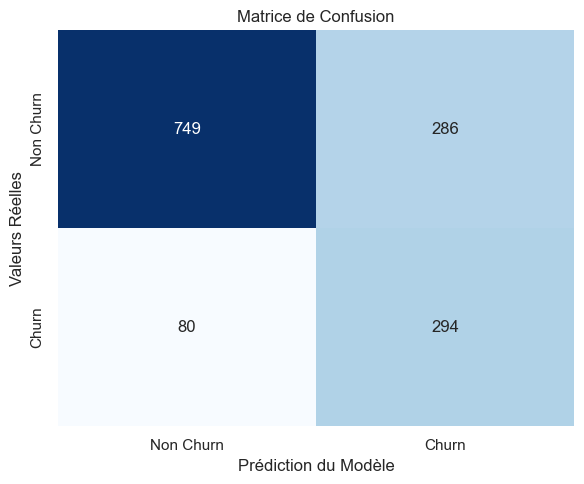

In [23]:
# Affichage des métriques clés
metrics_result = evaluate_classification_model(y_test, y_pred, y_prob)
display(metrics_result)

# Affichage de la matrice de confusion
plot_custom_confusion_matrix(y_test, y_pred)

Score ROC AUC : 0.8417


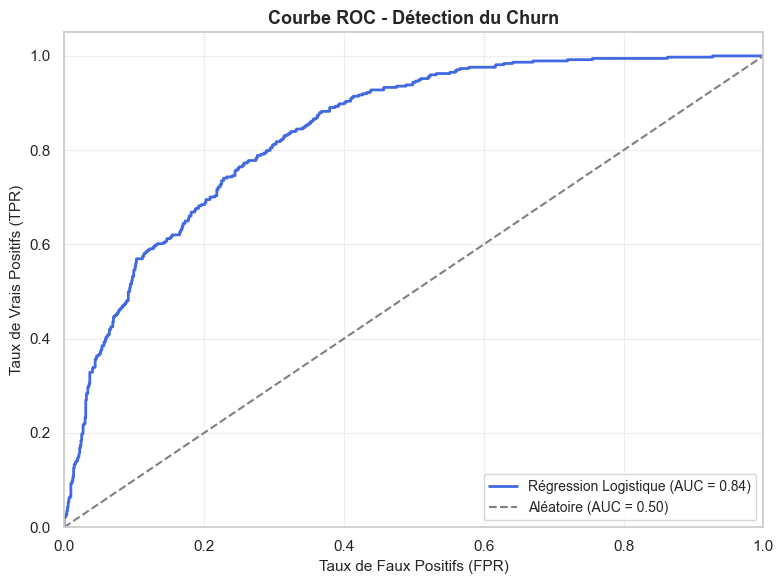

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Calcul du score ROC AUC
auc_score = roc_auc_score(y_test, y_prob)
print(f"Score ROC AUC : {auc_score:.4f}")

# 2. Calcul des taux de faux positifs (FPR) et de vrais positifs (TPR)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# 3. Tracé de la courbe
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='royalblue', lw=2, label=f'Régression Logistique (AUC = {auc_score:.2f})')

# Ligne diagonale de référence (classifieur aléatoire)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Aléatoire (AUC = 0.50)')

# Configuration des axes et du graphique
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=11)
plt.title('Courbe ROC - Détection du Churn', fontsize=13, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)

# Affichage
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# FEATURE ENGINEERING : Création de nouvelles variables
# ==========================================

# 1. Nombre total de services optionnels souscrits par le client
service_cols = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
df_preprocessed['TotalServices'] = df_preprocessed[service_cols].sum(axis=1)

# 2. Ratio Charges / Ancienneté (effort de paiement moyen par mois, +1 pour éviter division par 0)
df_preprocessed['ChargePerTenure'] = df_preprocessed['TotalCharges'] / (df_preprocessed['tenure'] + 1)

# 3. Indicateur de nouveau client (1 si <= 12 mois d'ancienneté, 0 sinon)
df_preprocessed['IsNewCustomer'] = (df_preprocessed['tenure'] <= 12).astype(int)

print("✔ Nouvelles variables créées avec succès !")
# Aperçu rapide des nouvelles colonnes
df_preprocessed[['tenure', 'TotalCharges', 'TotalServices', 'ChargePerTenure', 'IsNewCustomer']].head(3)